# Prediction of future quarterly metrics from results of `Lead_Lag_Analysis.ipynb`

In [325]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from typing import Union, Tuple

# Set directory paths
CODE_DIR = Path(os.path.abspath('')).resolve()
if CODE_DIR.name != 'Code' and (CODE_DIR / 'Code').exists():
    CODE_DIR = CODE_DIR / 'Code'
DATA_DIR = CODE_DIR.parent / 'Data' if CODE_DIR.name == 'Code' else CODE_DIR / 'Data'
RESULTS_DIR = CODE_DIR.parent / 'Results'
SUMMARIES_DIR = RESULTS_DIR / 'Summaries'

# Plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['figure.dpi'] = 130

# To store ML model evaluation results
lr_eval_results = []


In [326]:
# Define information of each quarterly metric
metric_configs = [
    {
        'col': 'revenue (USD)',
        'title': '1. Revenue (USD)',
        'color': '#08519c',
        'type': 'currency_b',
    },
    {
        'col': 'revenue_qoq (%)',
        'title': '2. Revenue QoQ Growth Rate (%)',
        'color': '#3182bd',
        'type': 'pct',
    },
    {
        'col': 'revenue_yoy (%)',
        'title': '3. Revenue YoY Growth Rate (%)',
        'color': '#6baed6',
        'type': 'pct',
    },
    {
        'col': 'rpo (USD)',
        'title': '4. Remaining Performance Obligations (RPO) (USD)',
        'color': '#a63603',
        'type': 'currency_b',
    },
    {
        'col': 'rpo_qoq (%)',
        'title': '5. RPO QoQ Growth Rate (%)',
        'color': '#e6550d',
        'type': 'pct',
    },
    {
        'col': 'rpo_yoy (%)',
        'title': '6. RPO YoY Growth Rate (%)',
        'color': '#fd8d3c',
        'type': 'pct',
    },
    {
        'col': 'billings (USD)',
        'title': '7. Calculated Billings (USD)',
        'color': '#006d2c',
        'type': 'currency_b',
    },
    {
        'col': 'billings_qoq (%)',
        'title': '8. Billings QoQ Growth Rate (%)',
        'color': '#31a354',
        'type': 'pct',
    },
    {
        'col': 'billings_yoy (%)',
        'title': '9. Billings YoY Growth Rate (%)',
        'color': '#74c476',
        'type': 'pct',
    },
    {
        'col': 'large_customer_count',
        'title': '10. Number of Large Customers (ARR >= $100k)',
        'color': '#54278f',
        'type': 'count',
    },
    {
        'col': 'large_customer_qoq (%)',
        'title': '11. Large Customer QoQ Growth Rate (%)',
        'color': '#756bb1',
        'type': 'pct',
    },
    {
        'col': 'large_customer_yoy (%)',
        'title': '12. Large Customer YoY Growth Rate (%)',
        'color': '#9e9ac8',
        'type': 'pct',
    },
    {
        'col': 'net_revenue_retention (%)',
        'title': '13. Net Revenue Retention (%)',
        'color': '#cb181d',
        'type': 'pct',
    }
]

In [327]:
# Choose type of lead-lag correlation to base your predictive model off of
lag_corr = 'pearsons' # 'hy' or 'pearsons'


## Load data from CSVs

In [328]:
# Load optimal windows and lags from CSV
df_hy_summary = pd.read_csv(SUMMARIES_DIR / 'hy_summary.csv')
df_pearsons_summary = pd.read_csv(SUMMARIES_DIR / 'pearsons_summary.csv')

def get_optimal_params(corr_type: str, source_name: str, metric_title: str):
    """
    Retrieve optimal rolling window length (window_days) and optimal lag (lag_days)
    for a given source and metric.
    """
    df_summary = df_hy_summary if corr_type.lower() == 'hy' else df_pearsons_summary
    metric_name = metric_title[3:].strip()
    match = df_summary[
        (df_summary['source'].astype(str).str.strip().str.lower() == source_name.strip().lower()) & 
        (df_summary['metric'].astype(str).str.strip().str.lower() == metric_name.lower())
    ]
    if not match.empty:
        win_col = 'optimal window' if 'optimal window' in match.columns else ('n_hat' if 'n_hat' in match.columns else None)
        lag_col = 'optimal lag' if 'optimal lag' in match.columns else ('l_hat' if 'l_hat' in match.columns else None)
        window = int(match[win_col].values[0]) if win_col else None
        lag = int(match[lag_col].values[0]) if lag_col else None
        return window, lag
    return None, None

for cfg in metric_configs:
    cfg['pypl_returns_window'], cfg['pypl_returns_lag_days'] = get_optimal_params(lag_corr, 'PYPL Returns', cfg['title'])
    cfg['tech_headlines_window'], cfg['tech_headlines_lag_days'] = get_optimal_params(lag_corr, 'Tech Headlines Score', cfg['title'])
    cfg['announcements_window'], cfg['announcements_lag_days'] = get_optimal_params(lag_corr, 'Product Releases Frequency', cfg['title'])

In [329]:
csv_path = DATA_DIR / 'qtrly_metrics.csv'
if not csv_path.exists():
    csv_path = Path('../Data/qtrly_metrics.csv')

df_metrics = pd.read_csv(csv_path)
df_metrics['timestamp_utc'] = pd.to_datetime(df_metrics['timestamp_utc'])
df_metrics = df_metrics.set_index('timestamp_utc').sort_index()
print(f"Loaded {len(df_metrics)} rows from qtrly_metrics.csv.")

Loaded 30 rows from qtrly_metrics.csv.


In [330]:
# NASDAQ:PYPL returns
s_pypl_returns = pd.read_csv(
    DATA_DIR / 'pypl_returns.csv', 
    parse_dates=['timestamp_utc']
).set_index('timestamp_utc')['return'].dropna().sort_index()

# Cloud tech-related news headlines 
s_tech_headlines = pd.read_csv(
    DATA_DIR / 'tech_headlines.csv', 
    parse_dates=['timestamp_utc']
).set_index('timestamp_utc')['news_score'].dropna().sort_index()

# Datadog product releases
s_announcements = pd.read_csv(
    DATA_DIR / 'announcements.csv', 
    parse_dates=['timestamp_utc']
)
s_announcements = s_announcements[s_announcements['product_release'] == True].set_index('timestamp_utc')['product_release'].sort_index()

def get_rolling_pypl(window_days: int) -> pd.Series:
    """Compute rolling average of PYPL returns for a given window length in days."""
    return s_pypl_returns.rolling(f'{window_days}D', min_periods=1).mean()

def get_rolling_tech_headlines(window_days: int) -> pd.Series:
    """Compute rolling average of tech headlines sentiment scores for a given window length in days."""
    return s_tech_headlines.rolling(f'{window_days}D', min_periods=1).mean()

def get_rolling_announcements(window_days: int) -> pd.Series:
    """Compute rolling frequency count of product releases for a given window length in days."""
    return s_announcements.resample('D').size().rolling(f'{window_days}D', min_periods=1).sum()

print("Created all pandas.Series and rolling predictor generators.")


Created all pandas.Series and rolling predictor generators.


## Functions

In [331]:
def extract_time_and_values(
    data: Union[pd.Series, np.ndarray, list, Tuple[np.ndarray, np.ndarray]]
) -> Tuple[np.ndarray, np.ndarray]:
    '''
    Extracts timestamps (in seconds/float) and values.
    '''
    if isinstance(data, pd.Series):
        values = data.to_numpy(dtype=np.float64)
        if isinstance(data.index, pd.DatetimeIndex):
            # Convert datetime to seconds
            timestamps = data.index.astype(np.int64) / 1e9
        else:
            timestamps = np.asarray(data.index, dtype=np.float64)
    elif isinstance(data, (tuple, list)) and len(data) == 2 and hasattr(data[0], '__len__'):
        timestamps = np.asarray(data[0], dtype=np.float64)
        values = np.asarray(data[1], dtype=np.float64)
    elif isinstance(data, np.ndarray) and data.ndim == 2 and data.shape[1] == 2:
        timestamps = data[:, 0].astype(np.float64)
        values = data[:, 1].astype(np.float64)
    else:
        raise ValueError(
            "Input must be a pd.Series, a (timestamps, values) tuple, or an (N, 2) numpy array."
        )
    # Ensure output data is sorted from earliest to latest timestamp
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    values = values[sort_idx]
    return np.array(timestamps), np.array(values)

def align_timestamps(s1, s2, s1_lag_days=0):
    '''
    Time-shifts s1 by `s1_lag_days` days and aligns the values of two datasets.
    Returns the aligned values and the time differences in days.
    '''
    if s1_lag_days is None:
        s1_lag_days = 0

    t1, raw_data1 = extract_time_and_values(s1)
    t2, raw_data2 = extract_time_and_values(s2)

    # Shift s1 timestamps to the future. 86400s = 1 day
    t1 = t1 + 86400 * s1_lag_days

    # Get overlapping time window where both series have valid observations
    start_time = max(t1[0], t2[0])
    end_time = min(t1[-1], t2[-1])

    # Keep only target series (s2) data that falls within overlap period
    valid_mask2 = (t2 >= start_time) & (t2 <= end_time)
    valid_t2 = t2[valid_mask2]
    data2 = raw_data2[valid_mask2]

    # Find the index of the latest timestamp in the shifted t1
    matched_idx = np.searchsorted(t1, valid_t2, side='right') - 1

    # Keep only predictor series (s1) data that can be mapped to target series (s2)
    valid_t1 = t1[matched_idx]
    data1 = raw_data1[matched_idx]

    # Amount of days that the actual shifted s1 timestamps were in the past compared to 
    # s1 timestamps ideally shifted by lag_days.
    diffs = (valid_t2 - valid_t1) / 86400

    return data1, data2, diffs


## Linear regression

In [332]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Source 1: PYPL returns

=== Linear Regression: PYPL Returns ===

1. Revenue (USD) (Window=2d, Lag=80d): R^2=-9.26, RMSE=4.76e+08
2. Revenue QoQ Growth Rate (%) (Window=2d, Lag=45d): R^2=-4.27, RMSE=4.88e+00
3. Revenue YoY Growth Rate (%) (Window=2d, Lag=19d): R^2=-34.62, RMSE=2.09e+01
4. Remaining Performance Obligations (RPO) (USD) (Window=2d, Lag=80d): R^2=-6.00, RMSE=1.71e+09
10. Number of Large Customers (ARR >= $100k) (Window=2d, Lag=80d): R^2=-11.92, RMSE=1.60e+03


11. Large Customer QoQ Growth Rate (%) (Window=1d, Lag=64d): R^2=-6.21, RMSE=4.07e+00


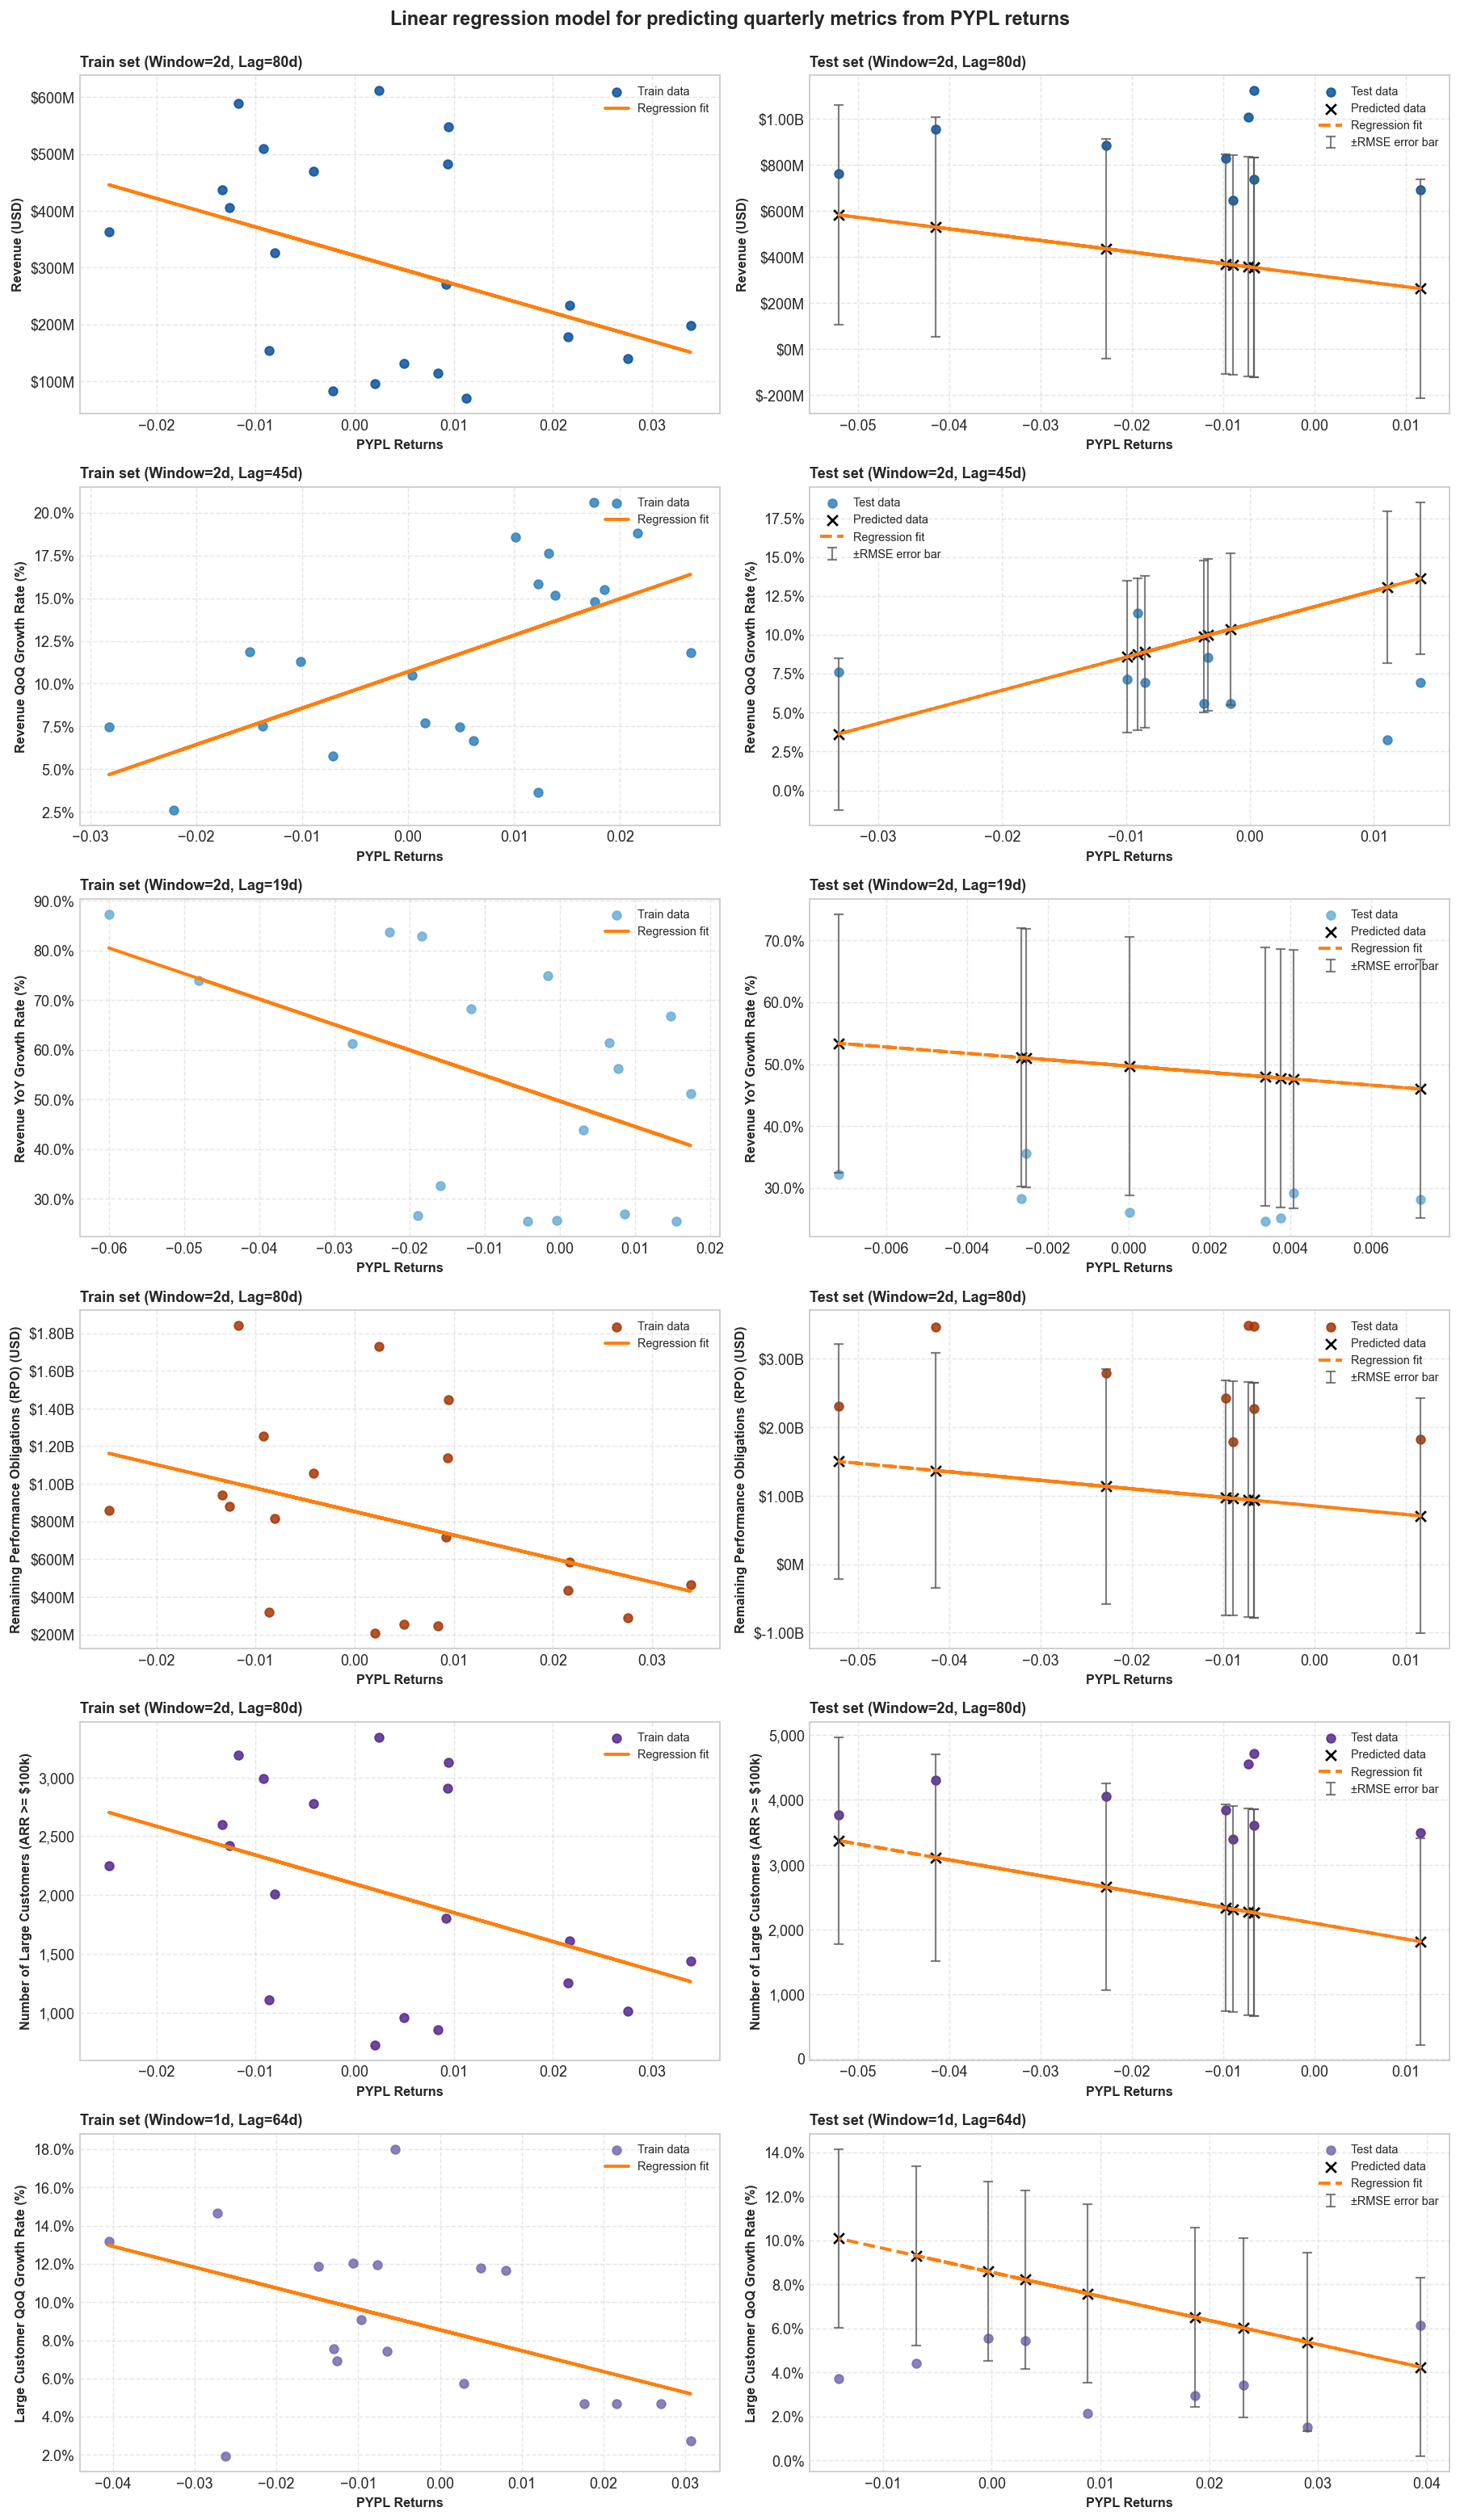

In [333]:
# Ignore metrics where PYPL returns do not lead the quarterly metrics
valid_configs = [cfg for cfg in metric_configs if cfg.get('pypl_returns_lag_days') is not None and cfg.get('pypl_returns_window') is not None]

n_plots = len(valid_configs)
fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4 * n_plots))
if n_plots == 1:
    axes = np.array([axes])

print(f"=== Linear Regression: PYPL Returns ===\n")
for idx, cfg in enumerate(valid_configs):
    ax_train = axes[idx, 0]
    ax_test = axes[idx, 1]
    col = cfg['col']
    title = cfg['title']
    color = cfg['color']
    window_days = cfg['pypl_returns_window']
    lag_days = cfg['pypl_returns_lag_days']
    
    series = df_metrics[col].dropna()
    
    # Generate metric-specific rolling predictor with ideal window length
    s_predictor = get_rolling_pypl(window_days)
    
    # Map lagged x to y
    x, y, diffs = align_timestamps(s_predictor, series, lag_days)
    
    # Reshape x into 2D array
    x = x.reshape(-1, 1)
    
    # Chronological train-test split
    split_idx = int(len(x) * 0.7)
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Fit linear regression line
    regressor = LinearRegression().fit(x_train, y_train)
    y_train_pred = regressor.predict(x_train)
    y_test_pred = regressor.predict(x_test)
    
    # Evaluation metrics of test set
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    
    lr_eval_results.append({
        'source': 'PYPL Returns',
        'metric': title[3:].strip(),
        'optimal window': window_days,
        'optimal lag': lag_days,
        'linr_r2': r2,
        'linr_rmse': rmse
    })
    
    # Y-axis formatting
    if cfg['type'] == 'currency_b':
        formatter = ticker.FuncFormatter(lambda val, pos: f'${val/1e9:.2f}B' if abs(val) >= 1e9 else f'${val/1e6:.0f}M')
    elif cfg['type'] == 'pct':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{val:.1f}%')
    elif cfg['type'] == 'count':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{int(val):,}')
    else:
        formatter = None
    
    # Left plot, train set
    ax_train.scatter(x_train, y_train, color=color, alpha=0.85, s=35, label='Train data')
    ax_train.plot(x_train, y_train_pred, color='tab:orange', linewidth=2.2, label='Regression fit')
    ax_train.set_title(f"Train set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_train.set_xlabel("PYPL Returns", fontsize=9, fontweight='semibold')
    ax_train.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_train.legend(fontsize=8, loc='best')
    ax_train.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_train.yaxis.set_major_formatter(formatter)
    
    # Right plot, test set
    ax_test.scatter(x_test, y_test, color=color, alpha=0.85, s=35, label='Test data')
    ax_test.scatter(x_test, y_test_pred, color='black', marker='x', s=50, linewidths=1.5, label='Predicted data')
    ax_test.errorbar(
        x_test.flatten(),
        y_test_pred,
        yerr=rmse,
        fmt='none',
        ecolor='#555555',
        elinewidth=1.2,
        capsize=3.5,
        capthick=1.2,
        alpha=0.75,
        label='±RMSE error bar'
    )
    ax_test.plot(x_test, y_test_pred, color='tab:orange', linewidth=2.2, linestyle='--', label='Regression fit')
    ax_test.set_title(f"Test set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_test.set_xlabel("PYPL Returns", fontsize=9, fontweight='semibold')
    ax_test.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_test.legend(fontsize=8, loc='best')
    ax_test.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_test.yaxis.set_major_formatter(formatter)
    
    print(f"{title} (Window={window_days}d, Lag={lag_days}d): R^2={r2:.2f}, RMSE={rmse:.2e}")

plt.suptitle("Linear regression model for predicting quarterly metrics from PYPL returns", fontsize=13, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'linr_{lag_corr}_pypl_returns.png', dpi=150, bbox_inches='tight')
plt.show()


### Source 2: Tech headlines

=== Linear Regression: Tech Headlines ===

2. Revenue QoQ Growth Rate (%) (Window=20d, Lag=15d): R^2=-7.63, RMSE=4.49e+00
4. Remaining Performance Obligations (RPO) (USD) (Window=2d, Lag=77d): R^2=-8.28, RMSE=1.85e+09
9. Billings YoY Growth Rate (%) (Window=45d, Lag=63d): R^2=-16.65, RMSE=2.43e+01
12. Large Customer YoY Growth Rate (%) (Window=45d, Lag=63d): R^2=-30.62, RMSE=2.18e+01
13. Net Revenue Retention (%) (Window=45d, Lag=63d): R^2=-8.02, RMSE=6.53e+00


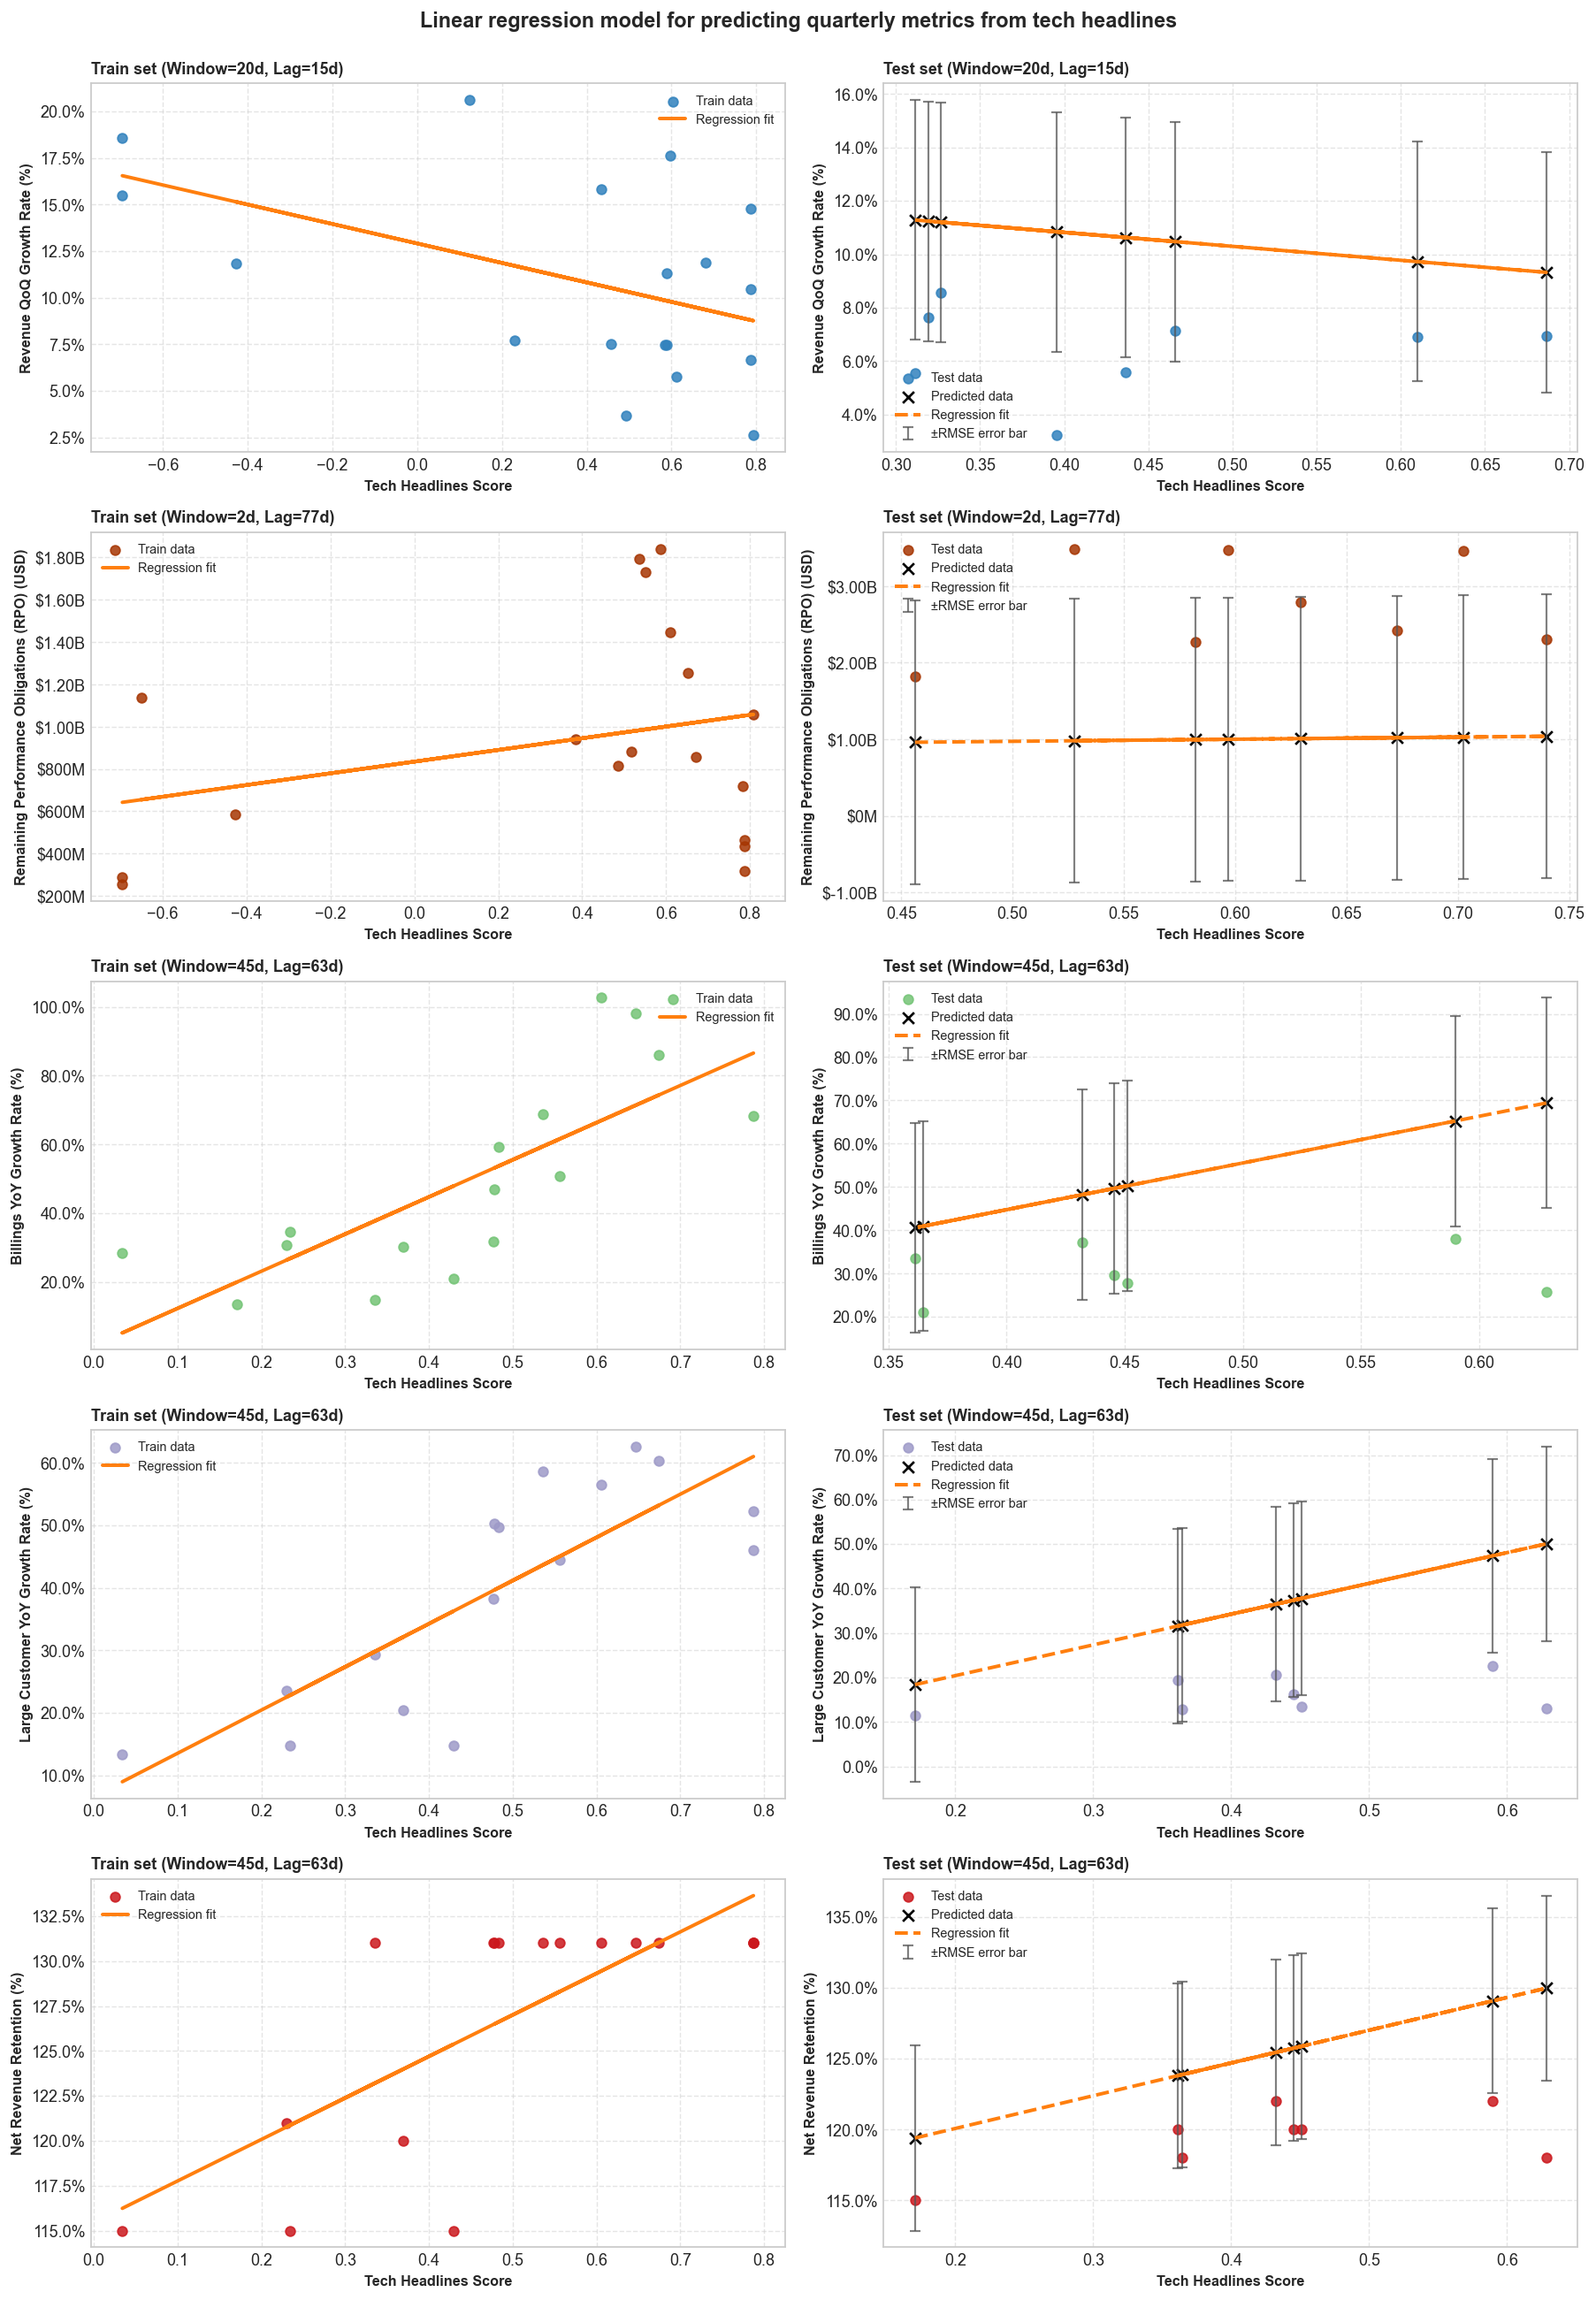

In [334]:
# Ignore metrics where tech headlines do not lead the quarterly metrics
valid_configs = [cfg for cfg in metric_configs if cfg.get('tech_headlines_lag_days') is not None and cfg.get('tech_headlines_window') is not None]

n_plots = len(valid_configs)
fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4 * n_plots))
if n_plots == 1:
    axes = np.array([axes])

print(f"=== Linear Regression: Tech Headlines ===\n")
for idx, cfg in enumerate(valid_configs):
    ax_train = axes[idx, 0]
    ax_test = axes[idx, 1]
    col = cfg['col']
    title = cfg['title']
    color = cfg['color']
    window_days = cfg['tech_headlines_window']
    lag_days = cfg['tech_headlines_lag_days']
    
    series = df_metrics[col].dropna()
    
    # Generate metric-specific rolling predictor with ideal window length
    s_predictor = get_rolling_tech_headlines(window_days)
    
    # Map lagged x to y
    x, y, diffs = align_timestamps(s_predictor, series, lag_days)
    
    # Reshape x into 2D array
    x = x.reshape(-1, 1)
    
    # Chronological train-test split
    split_idx = int(len(x) * 0.7)
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Fit linear regression line
    regressor = LinearRegression().fit(x_train, y_train)
    y_train_pred = regressor.predict(x_train)
    y_test_pred = regressor.predict(x_test)
    
    # Evaluation metrics of test set
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    
    lr_eval_results.append({
        'source': 'Tech Headlines Score',
        'metric': title[3:].strip(),
        'optimal window': window_days,
        'optimal lag': lag_days,
        'linr_r2': r2,
        'linr_rmse': rmse
    })
    
    # Y-axis formatting
    if cfg['type'] == 'currency_b':
        formatter = ticker.FuncFormatter(lambda val, pos: f'${val/1e9:.2f}B' if abs(val) >= 1e9 else f'${val/1e6:.0f}M')
    elif cfg['type'] == 'pct':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{val:.1f}%')
    elif cfg['type'] == 'count':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{int(val):,}')
    else:
        formatter = None
    
    # Left plot, train set
    ax_train.scatter(x_train, y_train, color=color, alpha=0.85, s=35, label='Train data')
    ax_train.plot(x_train, y_train_pred, color='tab:orange', linewidth=2.2, label='Regression fit')
    ax_train.set_title(f"Train set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_train.set_xlabel("Tech Headlines Score", fontsize=9, fontweight='semibold')
    ax_train.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_train.legend(fontsize=8, loc='best')
    ax_train.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_train.yaxis.set_major_formatter(formatter)
    
    # Right plot, test set
    ax_test.scatter(x_test, y_test, color=color, alpha=0.85, s=35, label='Test data')
    ax_test.scatter(x_test, y_test_pred, color='black', marker='x', s=50, linewidths=1.5, label='Predicted data')
    ax_test.errorbar(
        x_test.flatten(),
        y_test_pred,
        yerr=rmse,
        fmt='none',
        ecolor='#555555',
        elinewidth=1.2,
        capsize=3.5,
        capthick=1.2,
        alpha=0.75,
        label='±RMSE error bar'
    )
    ax_test.plot(x_test, y_test_pred, color='tab:orange', linewidth=2.2, linestyle='--', label='Regression fit')
    ax_test.set_title(f"Test set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_test.set_xlabel("Tech Headlines Score", fontsize=9, fontweight='semibold')
    ax_test.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_test.legend(fontsize=8, loc='best')
    ax_test.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_test.yaxis.set_major_formatter(formatter)
    
    print(f"{title} (Window={window_days}d, Lag={lag_days}d): R^2={r2:.2f}, RMSE={rmse:.2e}")

plt.suptitle("Linear regression model for predicting quarterly metrics from tech headlines", fontsize=13, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'linr_{lag_corr}_tech_headlines.png', dpi=150, bbox_inches='tight')
plt.show()


### Source 3: Announcements

=== Linear Regression: Announcements ===

1. Revenue (USD) (Window=15d, Lag=20d): R^2=-10.65, RMSE=4.41e+08
2. Revenue QoQ Growth Rate (%) (Window=6d, Lag=90d): R^2=-2.36, RMSE=3.90e+00
3. Revenue YoY Growth Rate (%) (Window=6d, Lag=63d): R^2=-35.75, RMSE=2.12e+01
4. Remaining Performance Obligations (RPO) (USD) (Window=15d, Lag=20d): R^2=-5.35, RMSE=1.59e+09
5. RPO QoQ Growth Rate (%) (Window=3d, Lag=51d): R^2=0.17, RMSE=8.72e+00
6. RPO YoY Growth Rate (%) (Window=2d, Lag=90d): R^2=-2.38, RMSE=2.03e+01
7. Calculated Billings (USD) (Window=15d, Lag=20d): R^2=-5.82, RMSE=4.45e+08
10. Number of Large Customers (ARR >= $100k) (Window=15d, Lag=20d): R^2=-16.40, RMSE=1.65e+03
11. Large Customer QoQ Growth Rate (%) (Window=1d, Lag=19d): R^2=-7.65, RMSE=4.72e+00
12. Large Customer YoY Growth Rate (%) (Window=3d, Lag=90d): R^2=-25.89, RMSE=2.01e+01


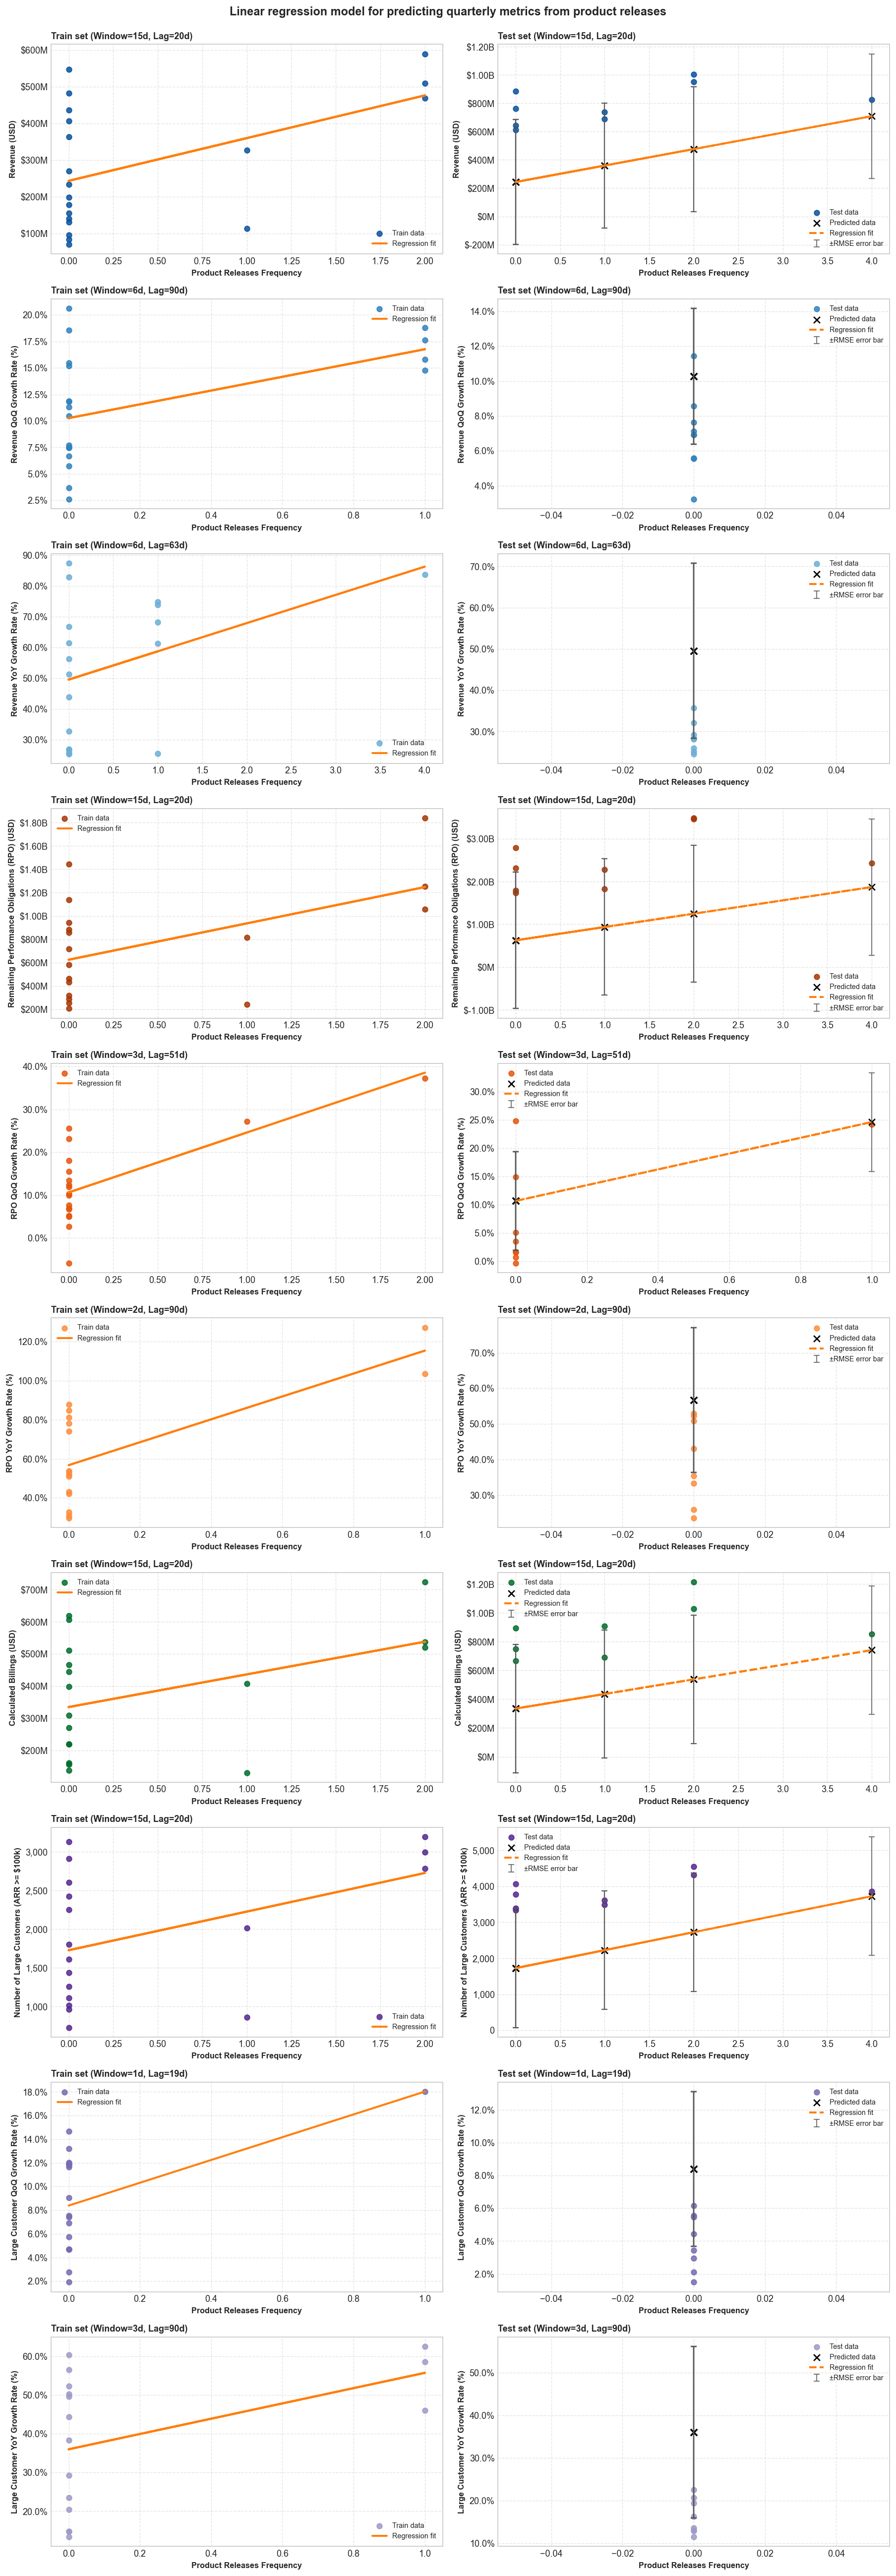

In [335]:
# Ignore metrics where product releases do not lead the quarterly metrics
valid_configs = [cfg for cfg in metric_configs if cfg.get('announcements_lag_days') is not None and cfg.get('announcements_window') is not None]

n_plots = len(valid_configs)
fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4 * n_plots))
if n_plots == 1:
    axes = np.array([axes])

print(f"=== Linear Regression: Announcements ===\n")
for idx, cfg in enumerate(valid_configs):
    ax_train = axes[idx, 0]
    ax_test = axes[idx, 1]
    col = cfg['col']
    title = cfg['title']
    color = cfg['color']
    window_days = cfg['announcements_window']
    lag_days = cfg['announcements_lag_days']
    
    series = df_metrics[col].dropna()
    
    # Generate metric-specific rolling predictor with ideal window length
    s_predictor = get_rolling_announcements(window_days)
    
    # Map lagged x to y
    x, y, diffs = align_timestamps(s_predictor, series, lag_days)
    
    # Reshape x into 2D array
    x = x.reshape(-1, 1)
    
    # Chronological train-test split
    split_idx = int(len(x) * 0.7)
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Fit linear regression line
    regressor = LinearRegression().fit(x_train, y_train)
    y_train_pred = regressor.predict(x_train)
    y_test_pred = regressor.predict(x_test)
    
    # Evaluation metrics of test set
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    
    lr_eval_results.append({
        'source': 'Product Releases Frequency',
        'metric': title[3:].strip(),
        'optimal window': window_days,
        'optimal lag': lag_days,
        'linr_r2': r2,
        'linr_rmse': rmse
    })
    
    # Y-axis formatting
    if cfg['type'] == 'currency_b':
        formatter = ticker.FuncFormatter(lambda val, pos: f'${val/1e9:.2f}B' if abs(val) >= 1e9 else f'${val/1e6:.0f}M')
    elif cfg['type'] == 'pct':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{val:.1f}%')
    elif cfg['type'] == 'count':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{int(val):,}')
    else:
        formatter = None
    
    # Left plot, train set
    ax_train.scatter(x_train, y_train, color=color, alpha=0.85, s=35, label='Train data')
    ax_train.plot(x_train, y_train_pred, color='tab:orange', linewidth=2.2, label='Regression fit')
    ax_train.set_title(f"Train set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_train.set_xlabel("Product Releases Frequency", fontsize=9, fontweight='semibold')
    ax_train.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_train.legend(fontsize=8, loc='best')
    ax_train.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_train.yaxis.set_major_formatter(formatter)
    
    # Right plot, test set
    ax_test.scatter(x_test, y_test, color=color, alpha=0.85, s=35, label='Test data')
    ax_test.scatter(x_test, y_test_pred, color='black', marker='x', s=50, linewidths=1.5, label='Predicted data')
    ax_test.errorbar(
        x_test.flatten(),
        y_test_pred,
        yerr=rmse,
        fmt='none',
        ecolor='#555555',
        elinewidth=1.2,
        capsize=3.5,
        capthick=1.2,
        alpha=0.75,
        label='±RMSE error bar'
    )
    ax_test.plot(x_test, y_test_pred, color='tab:orange', linewidth=2.2, linestyle='--', label='Regression fit')
    ax_test.set_title(f"Test set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_test.set_xlabel("Product Releases Frequency", fontsize=9, fontweight='semibold')
    ax_test.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_test.legend(fontsize=8, loc='best')
    ax_test.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_test.yaxis.set_major_formatter(formatter)
    
    print(f"{title} (Window={window_days}d, Lag={lag_days}d): R^2={r2:.2f}, RMSE={rmse:.2e}")

plt.suptitle("Linear regression model for predicting quarterly metrics from product releases", fontsize=13, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'linr_{lag_corr}_announcements.png', dpi=150, bbox_inches='tight')
plt.show()


## Random forest regression

In [336]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Set random_state to None for no set value.
random_state = 42

# RandomForestRegressor configuration
rf_params = {
    'n_estimators': 100,
    'random_state': random_state,
    'n_jobs': -1
}

# To store ML model evaluation results
rf_eval_results = []


### Source 1: PYPL returns

=== Random Forest Regression: PYPL Returns ===

1. Revenue (USD) (Window=2d, Lag=80d): R^2=-11.54, RMSE=5.26e+08
2. Revenue QoQ Growth Rate (%) (Window=2d, Lag=45d): R^2=-5.72, RMSE=5.52e+00
3. Revenue YoY Growth Rate (%) (Window=2d, Lag=19d): R^2=-37.93, RMSE=2.18e+01
4. Remaining Performance Obligations (RPO) (USD) (Window=2d, Lag=80d): R^2=-7.65, RMSE=1.91e+09
10. Number of Large Customers (ARR >= $100k) (Window=2d, Lag=80d): R^2=-16.43, RMSE=1.85e+03
11. Large Customer QoQ Growth Rate (%) (Window=1d, Lag=64d): R^2=-8.05, RMSE=4.56e+00


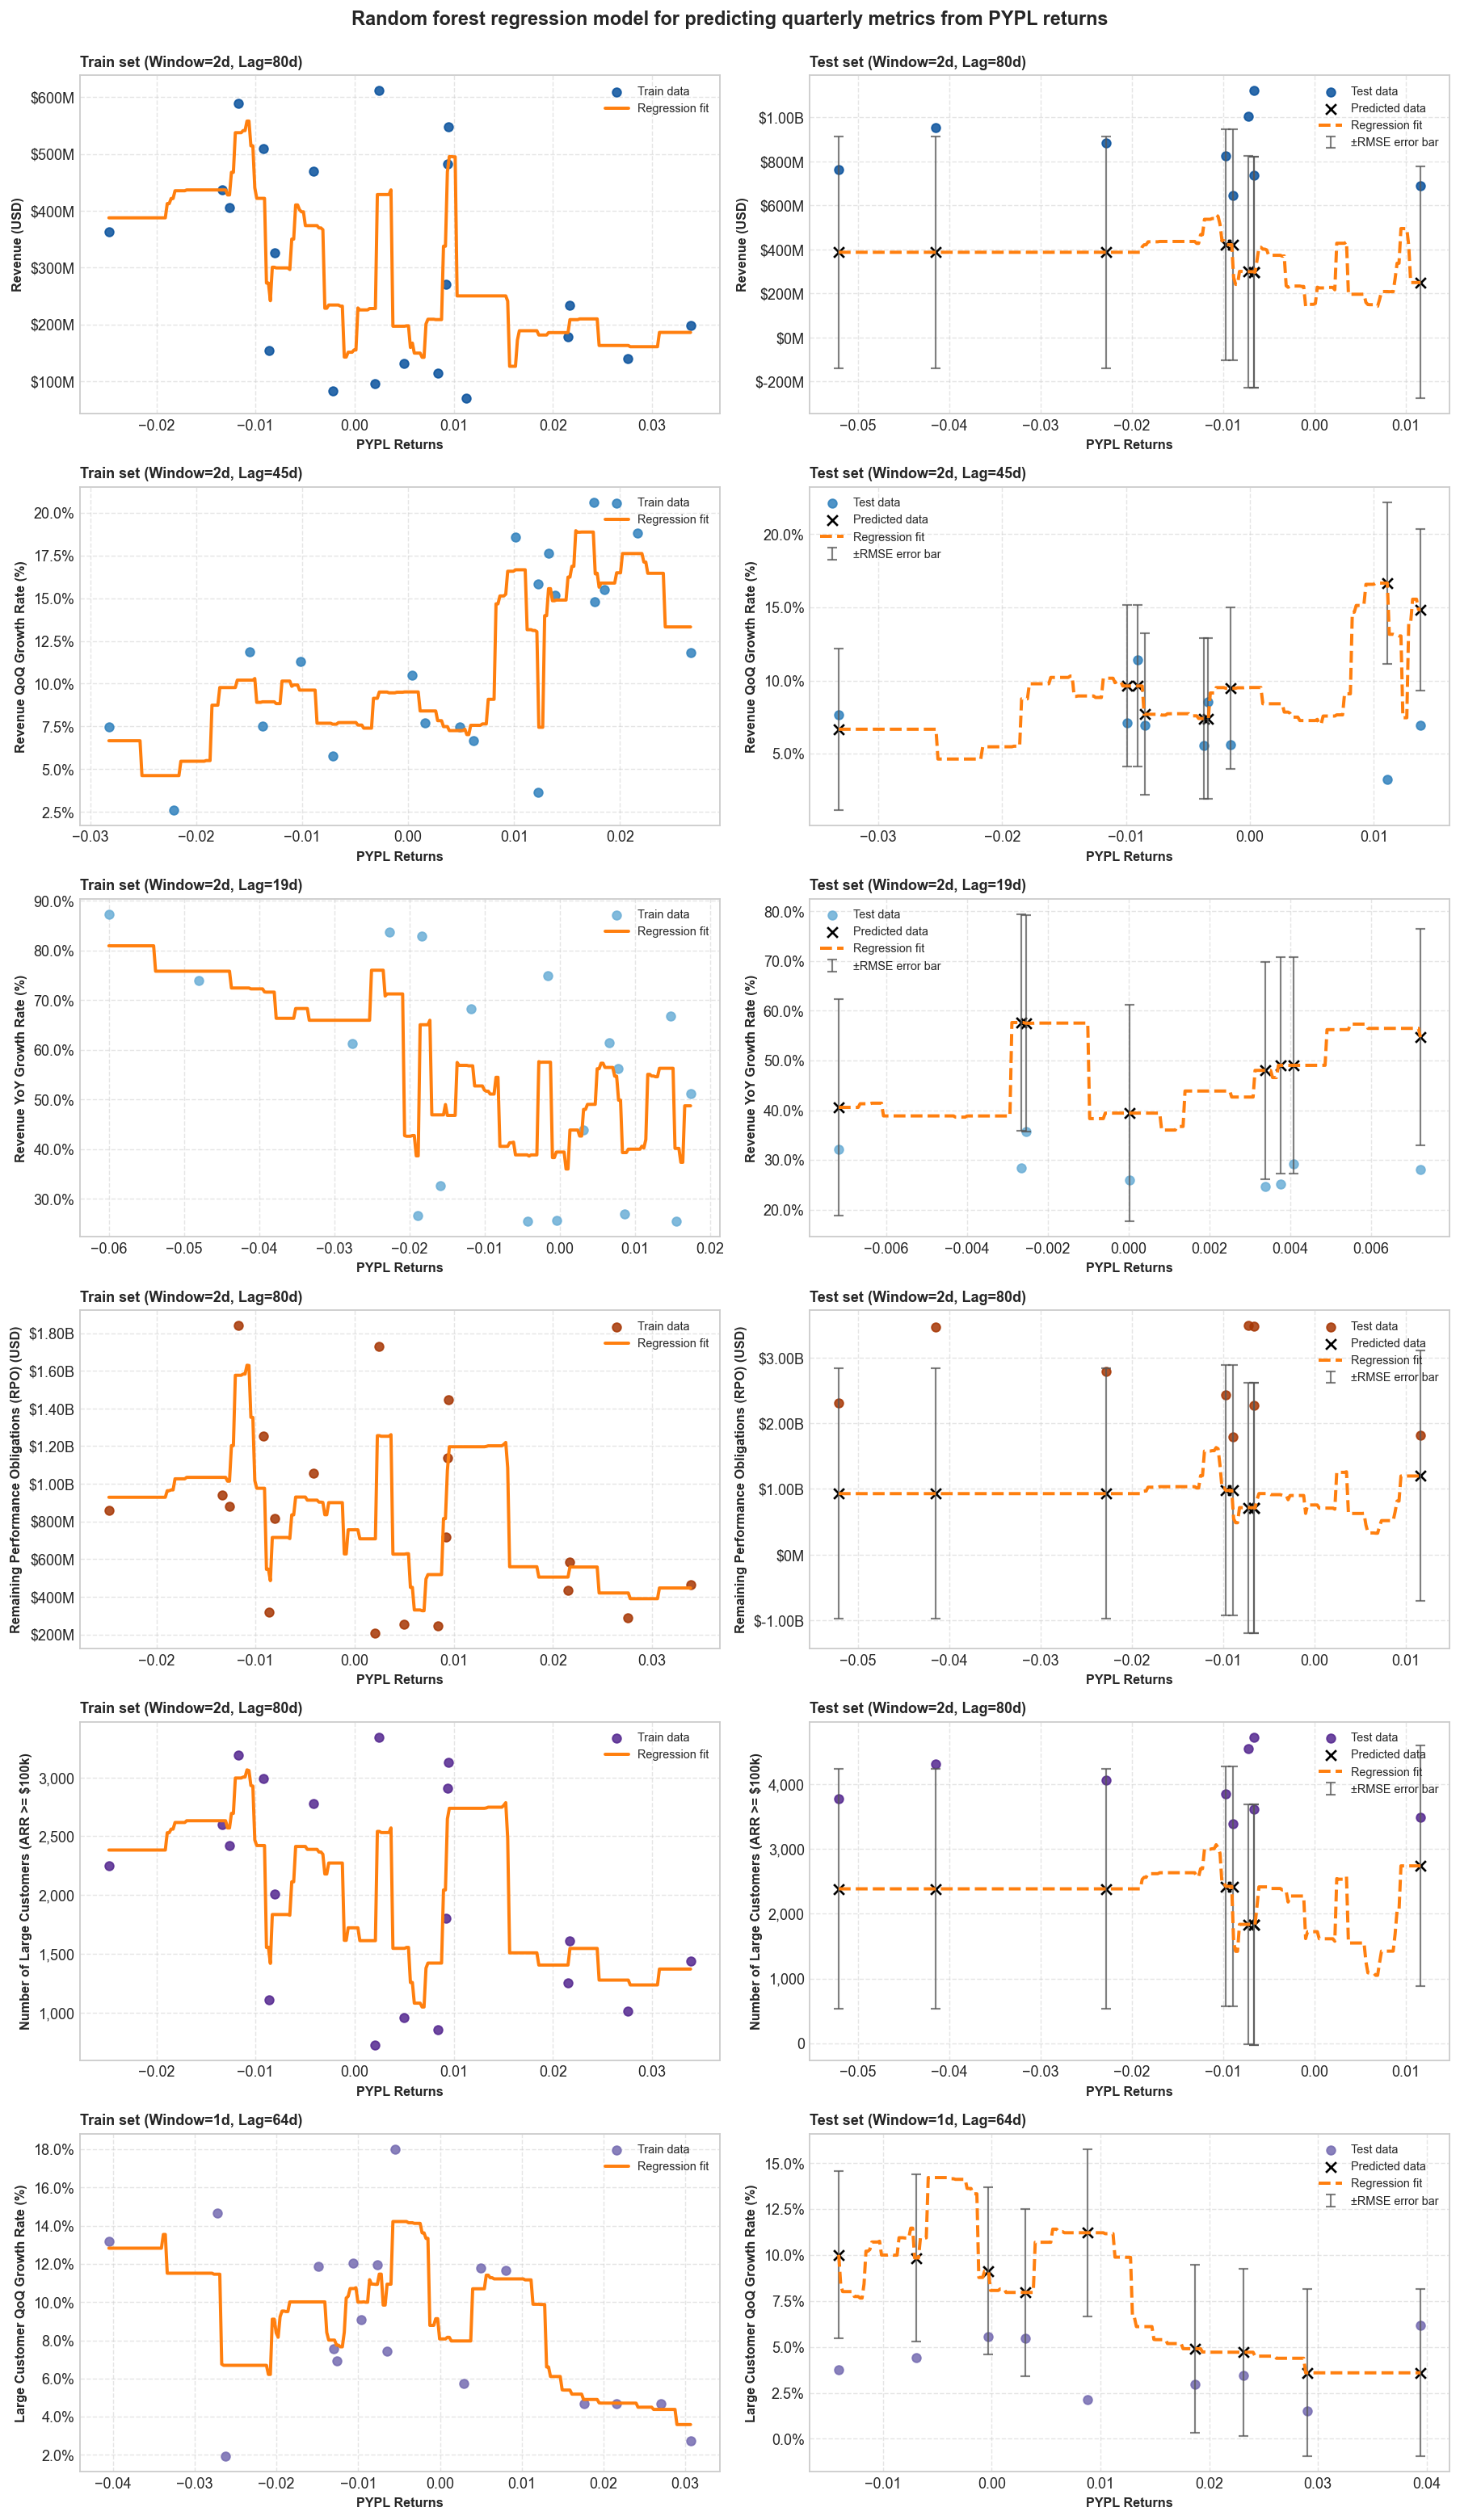

In [337]:
# Ignore metrics where PYPL returns do not lead the quarterly metrics
valid_configs = [cfg for cfg in metric_configs if cfg.get('pypl_returns_lag_days') is not None and cfg.get('pypl_returns_window') is not None]

n_plots = len(valid_configs)
fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4 * n_plots))
if n_plots == 1:
    axes = np.array([axes])

print(f"=== Random Forest Regression: PYPL Returns ===\n")
for idx, cfg in enumerate(valid_configs):
    ax_train = axes[idx, 0]
    ax_test = axes[idx, 1]
    col = cfg['col']
    title = cfg['title']
    color = cfg['color']
    window_days = cfg['pypl_returns_window']
    lag_days = cfg['pypl_returns_lag_days']
    
    series = df_metrics[col].dropna()
    
    # Generate metric-specific rolling predictor with ideal window length
    s_predictor = get_rolling_pypl(window_days)
    
    # Map lagged x to y
    x, y, diffs = align_timestamps(s_predictor, series, lag_days)
    
    # Reshape x into 2D array
    x = x.reshape(-1, 1)
    
    # Chronological train-test split
    split_idx = int(len(x) * 0.7)
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Fit random forest regression
    regressor = RandomForestRegressor(**rf_params).fit(x_train, y_train)
    y_train_pred = regressor.predict(x_train)
    y_test_pred = regressor.predict(x_test)
    
    # Evaluation metrics of test set
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    
    rf_eval_results.append({
        'source': 'PYPL Returns',
        'metric': title[3:].strip(),
        'optimal window': window_days,
        'optimal lag': lag_days,
        'rf_r2': r2,
        'rf_rmse': rmse
    })
    
    # Y-axis formatting
    if cfg['type'] == 'currency_b':
        formatter = ticker.FuncFormatter(lambda val, pos: f'${val/1e9:.2f}B' if abs(val) >= 1e9 else f'${val/1e6:.0f}M')
    elif cfg['type'] == 'pct':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{val:.1f}%')
    elif cfg['type'] == 'count':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{int(val):,}')
    else:
        formatter = None
    
    # Plot random forest fitted lines
    x_line_train = np.linspace(x_train.min(), x_train.max(), 300).reshape(-1, 1)
    y_line_train = regressor.predict(x_line_train)
    
    x_line_test = np.linspace(x_test.min(), x_test.max(), 300).reshape(-1, 1)
    y_line_test = regressor.predict(x_line_test)
    
    # Left plot, train set
    ax_train.scatter(x_train, y_train, color=color, alpha=0.85, s=35, label='Train data')
    ax_train.plot(x_line_train, y_line_train, color='tab:orange', linewidth=2.2, label='Regression fit')
    ax_train.set_title(f"Train set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_train.set_xlabel("PYPL Returns", fontsize=9, fontweight='semibold')
    ax_train.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_train.legend(fontsize=8, loc='best')
    ax_train.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_train.yaxis.set_major_formatter(formatter)
    
    # Right plot, test set
    ax_test.scatter(x_test, y_test, color=color, alpha=0.85, s=35, label='Test data')
    ax_test.scatter(x_test, y_test_pred, color='black', marker='x', s=50, linewidths=1.5, label='Predicted data')
    ax_test.errorbar(
        x_test.flatten(),
        y_test_pred,
        yerr=rmse,
        fmt='none',
        ecolor='#555555',
        elinewidth=1.2,
        capsize=3.5,
        capthick=1.2,
        alpha=0.75,
        label='±RMSE error bar'
    )
    ax_test.plot(x_line_test, y_line_test, color='tab:orange', linewidth=2.2, linestyle='--', label='Regression fit')
    ax_test.set_title(f"Test set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_test.set_xlabel("PYPL Returns", fontsize=9, fontweight='semibold')
    ax_test.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_test.legend(fontsize=8, loc='best')
    ax_test.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_test.yaxis.set_major_formatter(formatter)
    
    print(f"{title} (Window={window_days}d, Lag={lag_days}d): R^2={r2:.2f}, RMSE={rmse:.2e}")

plt.suptitle("Random forest regression model for predicting quarterly metrics from PYPL returns", fontsize=13, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'rf_{lag_corr}_pypl_returns.png', dpi=150, bbox_inches='tight')
plt.show()


### Source 2: Tech headlines

=== Random Forest Regression: Tech Headlines ===

2. Revenue QoQ Growth Rate (%) (Window=20d, Lag=15d): R^2=-10.54, RMSE=5.19e+00
4. Remaining Performance Obligations (RPO) (USD) (Window=2d, Lag=77d): R^2=-6.23, RMSE=1.63e+09
9. Billings YoY Growth Rate (%) (Window=45d, Lag=63d): R^2=-31.22, RMSE=3.28e+01
12. Large Customer YoY Growth Rate (%) (Window=45d, Lag=63d): R^2=-29.05, RMSE=2.13e+01
13. Net Revenue Retention (%) (Window=45d, Lag=63d): R^2=-7.07, RMSE=6.18e+00


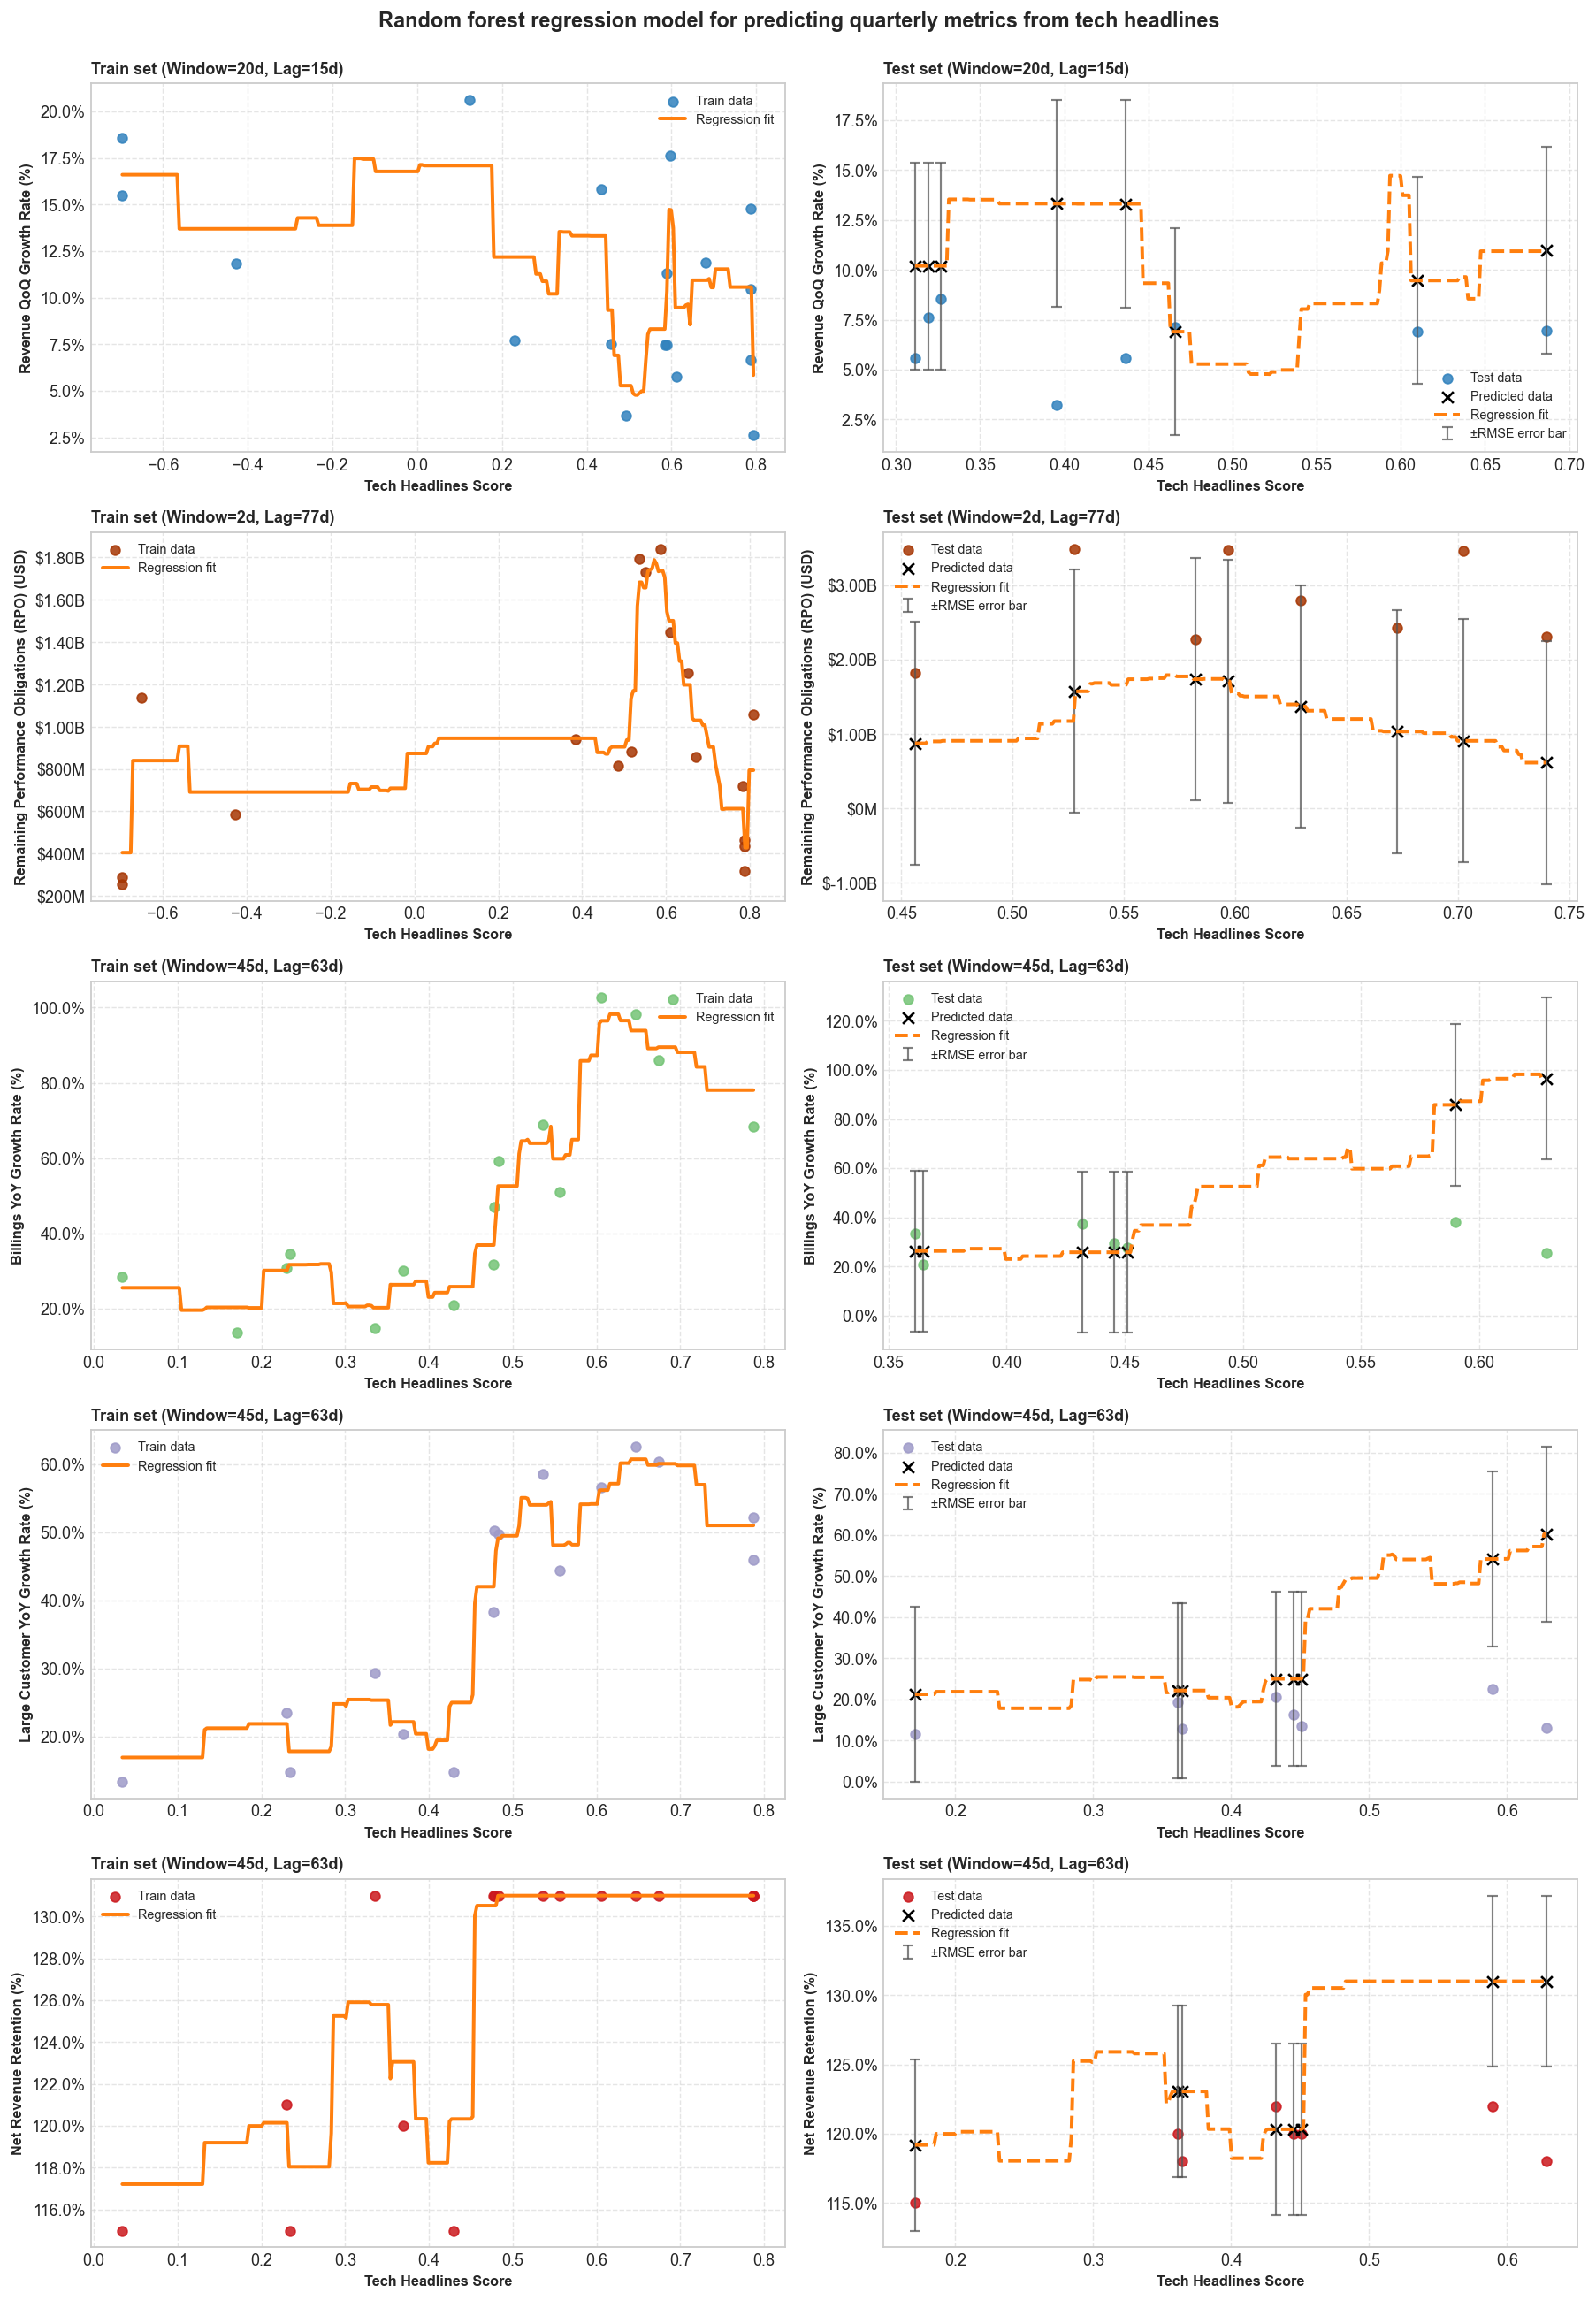

In [338]:
# Ignore metrics where tech headlines do not lead the quarterly metrics
valid_configs = [cfg for cfg in metric_configs if cfg.get('tech_headlines_lag_days') is not None and cfg.get('tech_headlines_window') is not None]

n_plots = len(valid_configs)
fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4 * n_plots))
if n_plots == 1:
    axes = np.array([axes])

print(f"=== Random Forest Regression: Tech Headlines ===\n")
for idx, cfg in enumerate(valid_configs):
    ax_train = axes[idx, 0]
    ax_test = axes[idx, 1]
    col = cfg['col']
    title = cfg['title']
    color = cfg['color']
    window_days = cfg['tech_headlines_window']
    lag_days = cfg['tech_headlines_lag_days']
    
    series = df_metrics[col].dropna()
    
    # Generate metric-specific rolling predictor with ideal window length
    s_predictor = get_rolling_tech_headlines(window_days)
    
    # Map lagged x to y
    x, y, diffs = align_timestamps(s_predictor, series, lag_days)
    
    # Reshape x into 2D array
    x = x.reshape(-1, 1)
    
    # Chronological train-test split
    split_idx = int(len(x) * 0.7)
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Fit random forest regression
    regressor = RandomForestRegressor(**rf_params).fit(x_train, y_train)
    y_train_pred = regressor.predict(x_train)
    y_test_pred = regressor.predict(x_test)
    
    # Evaluation metrics of test set
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    
    rf_eval_results.append({
        'source': 'Tech Headlines Score',
        'metric': title[3:].strip(),
        'optimal window': window_days,
        'optimal lag': lag_days,
        'rf_r2': r2,
        'rf_rmse': rmse
    })
    
    # Y-axis formatting
    if cfg['type'] == 'currency_b':
        formatter = ticker.FuncFormatter(lambda val, pos: f'${val/1e9:.2f}B' if abs(val) >= 1e9 else f'${val/1e6:.0f}M')
    elif cfg['type'] == 'pct':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{val:.1f}%')
    elif cfg['type'] == 'count':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{int(val):,}')
    else:
        formatter = None
    
    # Plot random forest fitted lines
    x_line_train = np.linspace(x_train.min(), x_train.max(), 300).reshape(-1, 1)
    y_line_train = regressor.predict(x_line_train)
    
    x_line_test = np.linspace(x_test.min(), x_test.max(), 300).reshape(-1, 1)
    y_line_test = regressor.predict(x_line_test)
    
    # Left plot, train set
    ax_train.scatter(x_train, y_train, color=color, alpha=0.85, s=35, label='Train data')
    ax_train.plot(x_line_train, y_line_train, color='tab:orange', linewidth=2.2, label='Regression fit')
    ax_train.set_title(f"Train set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_train.set_xlabel("Tech Headlines Score", fontsize=9, fontweight='semibold')
    ax_train.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_train.legend(fontsize=8, loc='best')
    ax_train.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_train.yaxis.set_major_formatter(formatter)
    
    # Right plot, test set
    ax_test.scatter(x_test, y_test, color=color, alpha=0.85, s=35, label='Test data')
    ax_test.scatter(x_test, y_test_pred, color='black', marker='x', s=50, linewidths=1.5, label='Predicted data')
    ax_test.errorbar(
        x_test.flatten(),
        y_test_pred,
        yerr=rmse,
        fmt='none',
        ecolor='#555555',
        elinewidth=1.2,
        capsize=3.5,
        capthick=1.2,
        alpha=0.75,
        label='±RMSE error bar'
    )
    ax_test.plot(x_line_test, y_line_test, color='tab:orange', linewidth=2.2, linestyle='--', label='Regression fit')
    ax_test.set_title(f"Test set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_test.set_xlabel("Tech Headlines Score", fontsize=9, fontweight='semibold')
    ax_test.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_test.legend(fontsize=8, loc='best')
    ax_test.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_test.yaxis.set_major_formatter(formatter)
    
    print(f"{title} (Window={window_days}d, Lag={lag_days}d): R^2={r2:.2f}, RMSE={rmse:.2e}")

plt.suptitle("Random forest regression model for predicting quarterly metrics from tech headlines", fontsize=13, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'rf_{lag_corr}_tech_headlines.png', dpi=150, bbox_inches='tight')
plt.show()


### Source 3: Announcements

=== Random Forest Regression: Announcements ===

1. Revenue (USD) (Window=15d, Lag=20d): R^2=-12.11, RMSE=4.68e+08
2. Revenue QoQ Growth Rate (%) (Window=6d, Lag=90d): R^2=-2.29, RMSE=3.86e+00
3. Revenue YoY Growth Rate (%) (Window=6d, Lag=63d): R^2=-34.82, RMSE=2.09e+01
4. Remaining Performance Obligations (RPO) (USD) (Window=15d, Lag=20d): R^2=-5.62, RMSE=1.63e+09
5. RPO QoQ Growth Rate (%) (Window=3d, Lag=51d): R^2=0.16, RMSE=8.76e+00
6. RPO YoY Growth Rate (%) (Window=2d, Lag=90d): R^2=-2.40, RMSE=2.04e+01
7. Calculated Billings (USD) (Window=15d, Lag=20d): R^2=-6.59, RMSE=4.70e+08
10. Number of Large Customers (ARR >= $100k) (Window=15d, Lag=20d): R^2=-18.44, RMSE=1.74e+03
11. Large Customer QoQ Growth Rate (%) (Window=1d, Lag=19d): R^2=-8.06, RMSE=4.83e+00
12. Large Customer YoY Growth Rate (%) (Window=3d, Lag=90d): R^2=-26.39, RMSE=2.03e+01


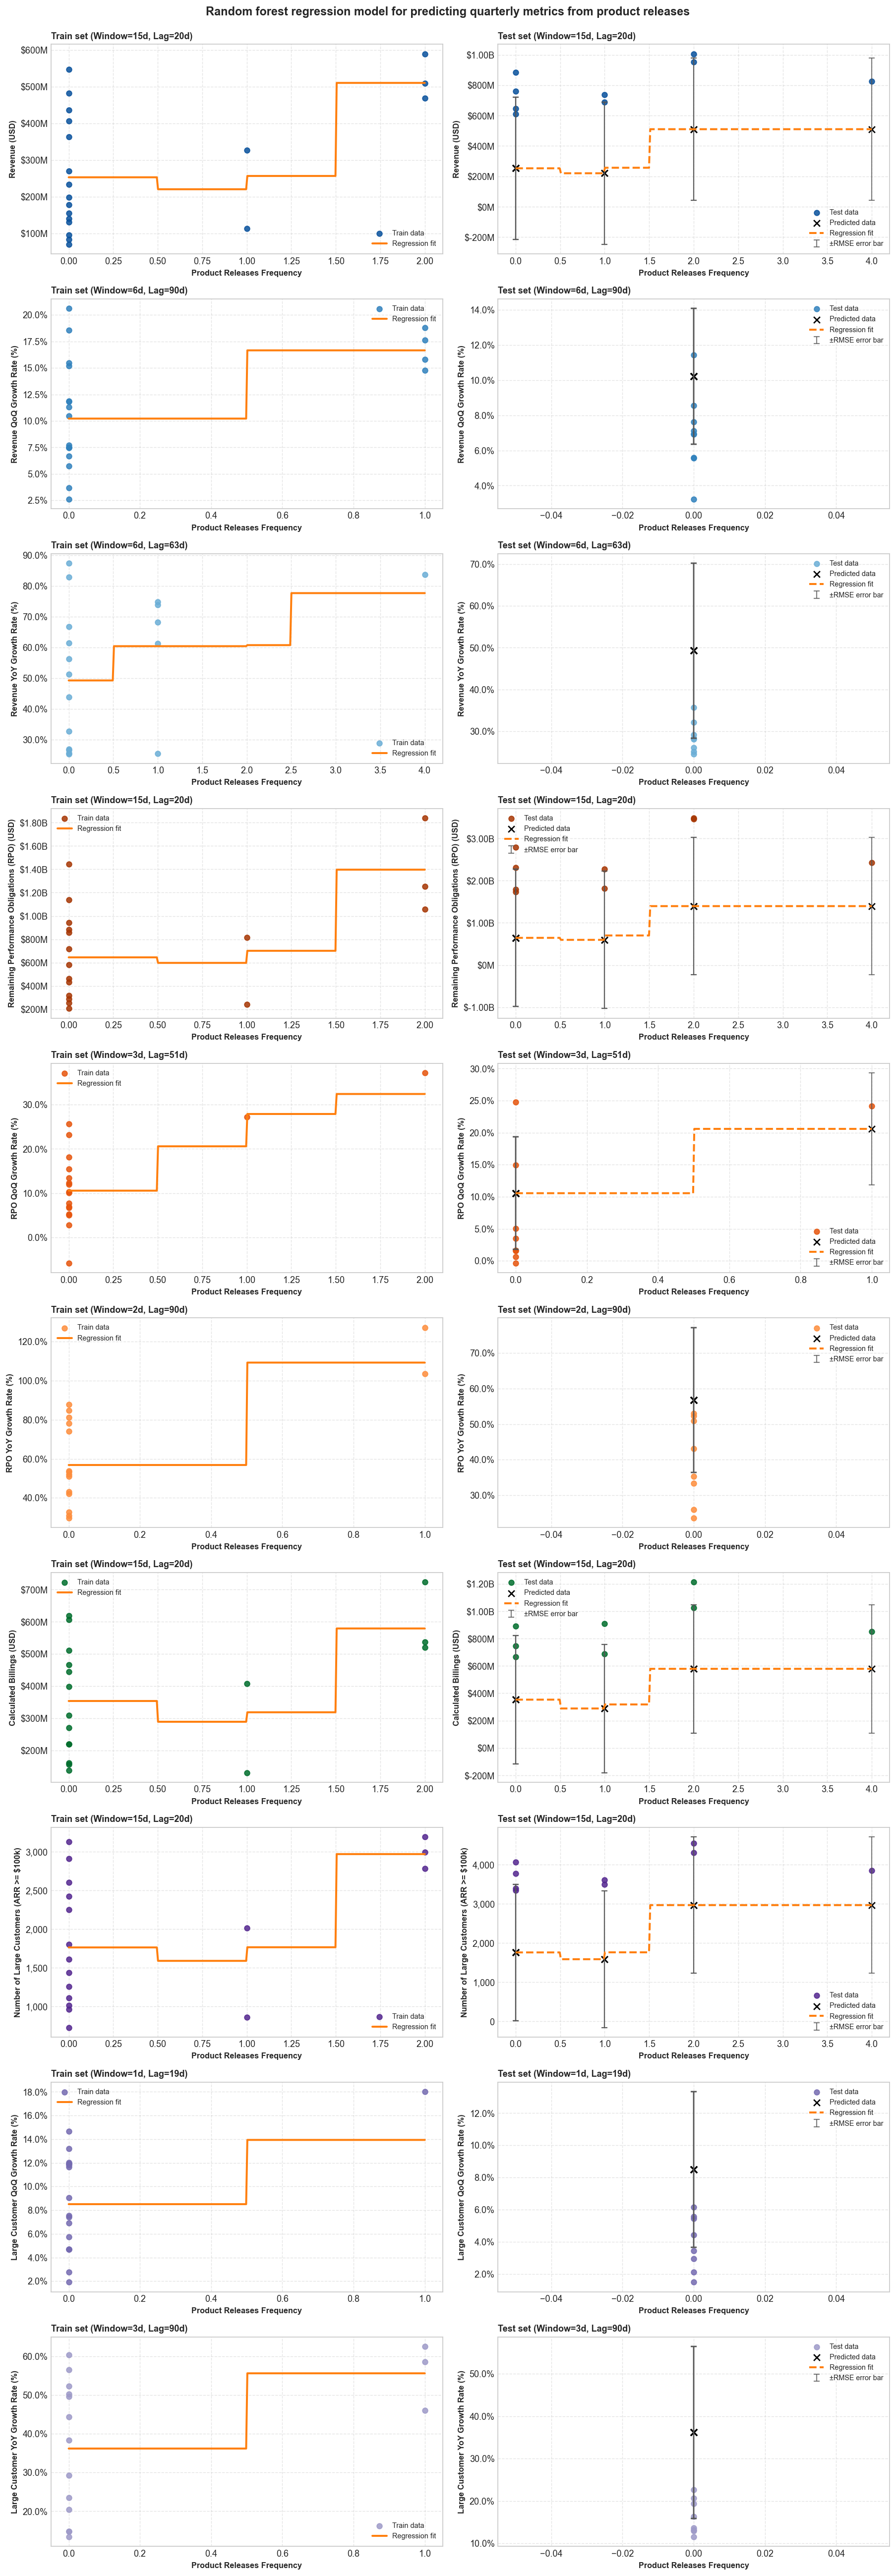

In [339]:
# Ignore metrics where product releases do not lead the quarterly metrics
valid_configs = [cfg for cfg in metric_configs if cfg.get('announcements_lag_days') is not None and cfg.get('announcements_window') is not None]

n_plots = len(valid_configs)
fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4 * n_plots))
if n_plots == 1:
    axes = np.array([axes])

print(f"=== Random Forest Regression: Announcements ===\n")
for idx, cfg in enumerate(valid_configs):
    ax_train = axes[idx, 0]
    ax_test = axes[idx, 1]
    col = cfg['col']
    title = cfg['title']
    color = cfg['color']
    window_days = cfg['announcements_window']
    lag_days = cfg['announcements_lag_days']
    
    series = df_metrics[col].dropna()
    
    # Generate metric-specific rolling predictor with ideal window length
    s_predictor = get_rolling_announcements(window_days)
    
    # Map lagged x to y
    x, y, diffs = align_timestamps(s_predictor, series, lag_days)
    
    # Reshape x into 2D array
    x = x.reshape(-1, 1)
    
    # Chronological train-test split
    split_idx = int(len(x) * 0.7)
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Fit random forest regression
    regressor = RandomForestRegressor(**rf_params).fit(x_train, y_train)
    y_train_pred = regressor.predict(x_train)
    y_test_pred = regressor.predict(x_test)
    
    # Evaluation metrics of test set
    r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    
    rf_eval_results.append({
        'source': 'Product Releases Frequency',
        'metric': title[3:].strip(),
        'optimal window': window_days,
        'optimal lag': lag_days,
        'rf_r2': r2,
        'rf_rmse': rmse
    })
    
    # Y-axis formatting
    if cfg['type'] == 'currency_b':
        formatter = ticker.FuncFormatter(lambda val, pos: f'${val/1e9:.2f}B' if abs(val) >= 1e9 else f'${val/1e6:.0f}M')
    elif cfg['type'] == 'pct':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{val:.1f}%')
    elif cfg['type'] == 'count':
        formatter = ticker.FuncFormatter(lambda val, pos: f'{int(val):,}')
    else:
        formatter = None
    
    # Plot random forest fitted lines
    x_line_train = np.linspace(x_train.min(), x_train.max(), 300).reshape(-1, 1)
    y_line_train = regressor.predict(x_line_train)
    
    x_line_test = np.linspace(x_test.min(), x_test.max(), 300).reshape(-1, 1)
    y_line_test = regressor.predict(x_line_test)
    
    # Left plot, train set
    ax_train.scatter(x_train, y_train, color=color, alpha=0.85, s=35, label='Train data')
    ax_train.plot(x_line_train, y_line_train, color='tab:orange', linewidth=2.2, label='Regression fit')
    ax_train.set_title(f"Train set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_train.set_xlabel("Product Releases Frequency", fontsize=9, fontweight='semibold')
    ax_train.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_train.legend(fontsize=8, loc='best')
    ax_train.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_train.yaxis.set_major_formatter(formatter)
    
    # Right plot, test set
    ax_test.scatter(x_test, y_test, color=color, alpha=0.85, s=35, label='Test data')
    ax_test.scatter(x_test, y_test_pred, color='black', marker='x', s=50, linewidths=1.5, label='Predicted data')
    ax_test.errorbar(
        x_test.flatten(),
        y_test_pred,
        yerr=rmse,
        fmt='none',
        ecolor='#555555',
        elinewidth=1.2,
        capsize=3.5,
        capthick=1.2,
        alpha=0.75,
        label='±RMSE error bar'
    )
    ax_test.plot(x_line_test, y_line_test, color='tab:orange', linewidth=2.2, linestyle='--', label='Regression fit')
    ax_test.set_title(f"Test set (Window={window_days}d, Lag={lag_days}d)", fontsize=10, fontweight='bold', loc='left')
    ax_test.set_xlabel("Product Releases Frequency", fontsize=9, fontweight='semibold')
    ax_test.set_ylabel(title[3:].strip(), fontsize=9, fontweight='semibold')
    ax_test.legend(fontsize=8, loc='best')
    ax_test.grid(True, linestyle='--', alpha=0.5)
    if formatter:
        ax_test.yaxis.set_major_formatter(formatter)
    
    print(f"{title} (Window={window_days}d, Lag={lag_days}d): R^2={r2:.2f}, RMSE={rmse:.2e}")

plt.suptitle("Random forest regression model for predicting quarterly metrics from product releases", fontsize=13, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'rf_{lag_corr}_announcements.png', dpi=150, bbox_inches='tight')
plt.show()


## Save evaluation results to CSV

In [340]:
# Create DataFrames from evaluation lists
df_lr_eval = pd.DataFrame(lr_eval_results)
df_rf_eval = pd.DataFrame(rf_eval_results)

# Strip whitespace from string columns before merging
df_lr_eval['metric'] = df_lr_eval['metric'].astype(str).str.strip()
df_rf_eval['metric'] = df_rf_eval['metric'].astype(str).str.strip()
df_lr_eval['source'] = df_lr_eval['source'].astype(str).str.strip()
df_rf_eval['source'] = df_rf_eval['source'].astype(str).str.strip()

# Merge linear regression and random forest evaluation results
df_merged = pd.merge(
    df_lr_eval[['source', 'metric', 'optimal window', 'optimal lag', 'linr_r2', 'linr_rmse']],
    df_rf_eval[['source', 'metric', 'optimal window', 'optimal lag', 'rf_r2', 'rf_rmse']],
    on=['source', 'metric', 'optimal window', 'optimal lag'],
    how='inner'  # or 'left'
)

# Save to CSV
summary_csv_path = SUMMARIES_DIR / ('hy_summary.csv' if lag_corr.lower() == 'hy' else 'pearsons_summary.csv')

if summary_csv_path.exists():
    df_summary = pd.read_csv(summary_csv_path)
    df_summary['metric'] = df_summary['metric'].astype(str).apply(lambda m: m[3:].strip() if m[:2].rstrip('.').isdigit() else m.strip())
    df_summary['source'] = df_summary['source'].astype(str).str.strip()
    
    # Drop existing ML evaluation columns to update with fresh results
    cols_to_drop = [c for c in ['linr_r2', 'linr_rmse', 'rf_r2', 'rf_rmse'] if c in df_summary.columns]
    df_summary = df_summary.drop(columns=cols_to_drop)
    
    ml_eval = df_merged[['source', 'metric', 'linr_r2', 'linr_rmse', 'rf_r2', 'rf_rmse']].drop_duplicates(subset=['source', 'metric'])
    df_updated = pd.merge(
        df_summary,
        ml_eval,
        on=['source', 'metric'],
        how='left'
    )
    
    # Prevent duplicate rows
    df_updated = df_updated.drop_duplicates(subset=['source', 'metric']).reset_index(drop=True)
    
    # Enforce column order
    if lag_corr.lower() == 'hy':
        expected_cols = ['source', 'metric', 'optimal window', 'optimal lag', 'hy estimator', 'linr_r2', 'linr_rmse', 'rf_r2', 'rf_rmse']
    else:
        expected_cols = ['source', 'metric', 'optimal window', 'optimal lag', 'pearsons coeff', 'p-value', 'significant (p<0.05)', 'linr_r2', 'linr_rmse', 'rf_r2', 'rf_rmse']
    
    df_updated = df_updated[[c for c in expected_cols if c in df_updated.columns]]
    
    try:
        df_updated.to_csv(summary_csv_path, index=False)
        print(f"Successfully saved regression evaluation results to {summary_csv_path}.")
    except PermissionError:
        print(f"Note: {summary_csv_path} is locked by another program. Save skipped.")


Successfully saved regression evaluation results to C:\Users\limli\Documents\Job Applications\Assignments\FUNDA\Results\Summaries\pearsons_summary.csv.


## Summary of the best alternative data for predicting each quarterly metric
Use HY estimator linear regression results only. Get the alternative data giving the largest `linr_r2` of each quarterly metric.

In [ ]:
# Generate table summary of best alternative data for each quarterly metric using HY results
csv_hy_path = SUMMARIES_DIR / 'hy_summary.csv'
df_hy_summary = pd.read_csv(csv_hy_path)

# Clean metric and source strings
df_hy_summary['metric'] = df_hy_summary['metric'].astype(str).apply(lambda m: m[3:].strip() if m[:2].rstrip('.').isdigit() else m.strip())
df_hy_summary['source'] = df_hy_summary['source'].astype(str).str.strip()

# Set order of metrics according to matching metric_configs
metric_order = [cfg['title'].split('.', 1)[-1].strip() for cfg in metric_configs]

# Select alternative data yielding the highest linear regression R^2 for each metric
df_best_hy = df_hy_summary.dropna(subset=['linr_r2']).sort_values('linr_r2', ascending=False).groupby('metric', as_index=False).first()

# Reorder rows according to order of metrics
df_best_hy['metric_order'] = pd.Categorical(df_best_hy['metric'], categories=metric_order, ordered=True)
df_best_hy = df_best_hy.sort_values('metric_order').drop(columns=['metric_order']).reset_index(drop=True)

# Preserve existing manual inputs in 'to_backtest' if file exists
strongest_csv_path = SUMMARIES_DIR / 'strongest_correlations.csv'
if strongest_csv_path.exists() and strongest_csv_path.stat().st_size > 0:
    df_existing = pd.read_csv(strongest_csv_path)
    df_existing['metric'] = df_existing['metric'].astype(str).apply(lambda m: m[3:].strip() if m[:2].rstrip('.').isdigit() else m.strip())
    df_existing['source'] = df_existing['source'].astype(str).str.strip()
    
    if 'to_backtest' in df_existing.columns:
        df_best_hy = pd.merge(
            df_best_hy,
            df_existing[['source', 'metric', 'to_backtest']].drop_duplicates(subset=['source', 'metric']),
            on=['source', 'metric'],
            how='left'
        )

# Ensure 'to_backtest' column exists
if 'to_backtest' not in df_best_hy.columns:
    df_best_hy['to_backtest'] = ""

# Define final column structure with 'to_backtest' as the last column
output_cols = ['source', 'metric', 'optimal window', 'optimal lag', 'hy estimator', 'linr_r2', 'linr_rmse', 'to_backtest']
df_strongest = df_best_hy[[c for c in output_cols if c in df_best_hy.columns]]

# Save to CSV
try:
    df_strongest.to_csv(strongest_csv_path, index=False)
    print(f"Successfully saved strongest correlations summary to {strongest_csv_path}.")
except PermissionError:
    print(f"Note: {strongest_csv_path} is locked by another program. Save skipped.")

df_strongest
